# Sentiment Analysis using NLP Pipeline & Machine Learning

## Dataset Used
IMDb Movies Dataset

## Objective
Build a complete NLP Sentiment Analysis pipeline using:
- Text preprocessing
- Feature engineering
- Machine Learning models
- Model evaluation

Import Libraries

In [4]:
# ==============================
# Install Required Libraries
# ==============================

!pip install nltk pandas numpy matplotlib scikit-learn


# ==============================
# Import Required Libraries
# ==============================

import pandas as pd
import numpy as np
import re
import string

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Visualization
import matplotlib.pyplot as plt

# Feature Engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ==============================
# Download NLTK Resources
# ==============================

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


# ==============================
# Verify Installation
# ==============================

print("All libraries installed successfully!")

Defaulting to user installation because normal site-packages is not writeable
All libraries installed successfully!



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\desai\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\desai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Load Dataset

In [5]:
df = pd.read_csv("Dataset/IMDb movies.csv")
df.head()

C:\Users\desai\AppData\Local\Temp\ipykernel_8816\1487100078.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Dataset/IMDb movies.csv")


,imdb_title_id,title,original_title,year,date_published,genre,duration,country,language,director,...,actors,description,avg_vote,votes,budget,usa_gross_income,worlwide_gross_income,metascore,reviews_from_users,reviews_from_critics
0,tt0000009,Miss Jerry,Miss Jerry,1894,1894-10-09,Romance,45,USA,NaN,Alexander Black,...,"Blanche Bayliss, William Courtenay, Chauncey D...",The adventures of a female reporter in the 1890s.,5.9,154,NaN,NaN,NaN,NaN,1.0,2.0
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906,1906-12-26,"Biography, Crime, Drama",70,Australia,NaN,Charles Tait,...,"Elizabeth Tait, John Tait, Norman Campbell, Be...",True story of notorious Australian outlaw Ned ...,6.1,589,$ 2250,NaN,NaN,NaN,7.0,7.0
2,tt0001892,Den sorte drøm,Den sorte drøm,1911,1911-08-19,Drama,53,"Germany, Denmark",NaN,Urban Gad,...,"Asta Nielsen, Valdemar Psilander, Gunnar Helse...",Two men of high rank are both wooing the beaut...,5.8,188,NaN,NaN,NaN,NaN,5.0,2.0
3,tt0002101,Cleopatra,Cleopatra,1912,1912-11-13,"Drama, History",100,USA,English,Charles L. Gaskill,...,"Helen Gardner, Pearl Sindelar, Miss Fielding, ...",The fabled queen of Egypt's affair with Roman ...,5.2,446,$ 45000,NaN,NaN,NaN,25.0,3.0
4,tt0002130,L'Inferno,L'Inferno,1911,1911-03-06,"Adventure, Drama, Fantasy",68,Italy,Italian,"Francesco Bertolini, Adolfo Padovan",...,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",Loosely adapted from Dante's Divine Comedy and...,7.0,2237,NaN,NaN,NaN,NaN,31.0,14.0


Select Required Columns

In [6]:
df = df[['description', 'avg_vote']]
df.head()

,description,avg_vote
0,The adventures of a female reporter in the 1890s.,5.9
1,True story of notorious Australian outlaw Ned ...,6.1
2,Two men of high rank are both wooing the beaut...,5.8
3,The fabled queen of Egypt's affair with Roman ...,5.2
4,Loosely adapted from Dante's Divine Comedy and...,7.0


Remove Missing Values

In [7]:
df.dropna(inplace=True)

print(df.shape)

(83740, 2)


Create Sentiment Labels

We will create:

Positive → avg_vote >= 6  \
Negative → avg_vote < 6

In [8]:
df['sentiment'] = df['avg_vote'].apply(
    lambda x: 1 if x >= 6 else 0
)

df.head()

,description,avg_vote,sentiment
0,The adventures of a female reporter in the 1890s.,5.9,0
1,True story of notorious Australian outlaw Ned ...,6.1,1
2,Two men of high rank are both wooing the beaut...,5.8,0
3,The fabled queen of Egypt's affair with Roman ...,5.2,0
4,Loosely adapted from Dante's Divine Comedy and...,7.0,1


Class Distribution

sentiment
1    46593
0    37147
Name: count, dtype: int64


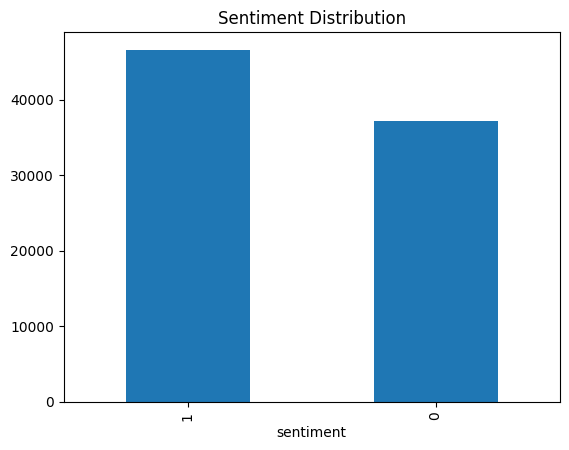

In [9]:
print(df['sentiment'].value_counts())
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

NLP Preprocessing Function

In [10]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\\S+|www\\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\\d+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Remove special characters
    tokens = [word for word in tokens if word.isalpha()]
    
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

Apply Preprocessing

In [11]:
df['clean_text'] = df['description'].apply(preprocess_text)
df[['description', 'clean_text']].head()

LookupError: 
**********************************************************************
  Resource 'punkt_tab' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'tokenizers/punkt_tab/english/'

  Searched in:
    - 'C:\\Users\\desai/nltk_data'
    - 'c:\\Program Files\\Python313\\nltk_data'
    - 'c:\\Program Files\\Python313\\share\\nltk_data'
    - 'c:\\Program Files\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\desai\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


Features & Labels

In [ ]:
X = df['clean_text']
y = df['sentiment']

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Bag of Words

In [ ]:
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [ ]:
#TF-IDF

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#Logistic Regression

lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

#Naive Bayes

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_pred = nb_model.predict(X_test_bow)

Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_bow, y_train)
dt_pred = dt_model.predict(X_test_bow)

Evaluation Function

In [ ]:
def evaluate_model(y_test, predictions, model_name):
    
    print(f"\\n{model_name}")
    print("-" * 30)
    
    print("Accuracy :", accuracy_score(y_test, predictions))
    print("Precision:", precision_score(y_test, predictions))
    print("Recall   :", recall_score(y_test, predictions))
    print("F1 Score :", f1_score(y_test, predictions))

Evaluate Models

In [ ]:
evaluate_model(y_test, lr_pred, "Logistic Regression")
evaluate_model(y_test, nb_pred, "Naive Bayes")
evaluate_model(y_test, dt_pred, "Decision Tree")

Classification Reports

In [ ]:
print(classification_report(y_test, lr_pred))
print(classification_report(y_test, nb_pred))
print(classification_report(y_test, dt_pred))

Model Comparison Table

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Decision Tree'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, dt_pred)
    ]
})

results

Visualization

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'])
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()